# 06 — Comparação de modelos (Medical Abstracts, target = urgência)

**Contexto:** o notebook 05 comparou as duas estratégias de target no Medical Abstracts TC Corpus (urgência de
3 classes vs. condição médica de 5 classes) e encontrou empate estatístico em qualidade de classificação —
a decisão pela **Estratégia 02 (urgência)** foi tomada por bater literalmente com o target pedido pelo
enunciado do Tech Challenge, sem precisar de nenhuma exceção. O baseline (TF-IDF+RandomForest, notebook 04) deu
73,1% accuracy / 0,720 macro F1 nesse split. Este notebook testa outros modelos leves e faz error analysis, sem
tomar decisão prematura — a escolha final considera performance, latência, tamanho e complexidade, não só a
métrica mais alta.

**Metodologia:**
- Split próprio do notebook 02 (`data/processed/train.csv`/`test.csv`), estratificado por `urgency`, já
  verificado sem overlap de texto entre treino e teste.
- `Pipeline` (TF-IDF ajustado só no treino) para todos os modelos, evitando vazamento pelo vocabulário.
- **Validação cruzada estratificada (3 folds) no treino** para cada modelo, antes de qualquer contato com o
  teste — o teste é usado só uma vez, para a avaliação final.
- Mesma seed (`RANDOM_STATE=42`) em tudo.
- Métricas: accuracy, macro F1, weighted F1, F1 por classe, tempo de treino, latência de inferência, tamanho do
  modelo serializado.

In [1]:
%matplotlib inline
import json
import os
import platform
import tempfile
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
np.random.seed(RANDOM_STATE)

print(f"python {platform.python_version()} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")
print(f"RANDOM_STATE = {RANDOM_STATE}")

RESULTS_DIR = "../data/experiments/results"
with open(f"{RESULTS_DIR}/baseline_results.json") as f:
    baseline = json.load(f)
print("Baseline (notebook 04, estratégia 02) carregado: RF split próprio ->",
      f"acc={baseline['strategy02_urgency']['accuracy']}, macro_f1={baseline['strategy02_urgency']['macro_f1']}")

python 3.11.15 | pandas 3.0.5 | scikit-learn 1.9.0
RANDOM_STATE = 42
Baseline (notebook 04, estratégia 02) carregado: RF split próprio -> acc=0.7306, macro_f1=0.7197


## Dados (split próprio do notebook 02 — estratégia 02, urgência)

In [2]:
train_s2 = pd.read_csv("../data/processed/train.csv")
test_s2 = pd.read_csv("../data/processed/test.csv")
order_ma = ["normal", "atencao", "urgente"]

x_train = train_s2["medical_abstract"]
y_train = train_s2["urgency"]
x_test = test_s2["medical_abstract"]
y_test = test_s2["urgency"]

print(f"treino: {len(x_train)} | teste: {len(x_test)}")
print(y_train.value_counts())

treino: 8981 | teste: 2246
urgency
urgente    3142
atencao    2993
normal     2846
Name: count, dtype: int64


## Modelos candidatos

In [3]:
MODELS = {
    "RandomForest (baseline)": lambda: (
        None  # reaproveita o resultado já medido no notebook 04 (mesmo split, mesma seed) —
              # evita retreinar 200 árvores de novo (~3.5s) só para repetir um número que já temos.
    ),
    "LogisticRegression": lambda: Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ]),
    "LinearSVC": lambda: Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
        ("clf", LinearSVC(random_state=RANDOM_STATE)),
    ]),
    "MultinomialNB": lambda: Pipeline([
        ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words="english")),
        ("clf", MultinomialNB()),
    ]),
}
print("Candidatos (além do baseline já medido):", [m for m in MODELS if m != "RandomForest (baseline)"])
print()
print("Por que esses três: são os modelos leves clássicos para classificação de texto com TF-IDF —")
print("LogisticRegression e LinearSVC lidam bem com features esparsas de alta dimensão (o caso do TF-IDF),")
print("MultinomialNB é o baseline probabilístico canônico para texto e é o mais barato de todos para treinar.")
print("Nenhum dos três precisa de GPU nem de tuning pesado — compatíveis com baixa latência e deploy simples.")

Candidatos (além do baseline já medido): ['LogisticRegression', 'LinearSVC', 'MultinomialNB']

Por que esses três: são os modelos leves clássicos para classificação de texto com TF-IDF —
LogisticRegression e LinearSVC lidam bem com features esparsas de alta dimensão (o caso do TF-IDF),
MultinomialNB é o baseline probabilístico canônico para texto e é o mais barato de todos para treinar.
Nenhum dos três precisa de GPU nem de tuning pesado — compatíveis com baixa latência e deploy simples.


## Validação cruzada (3 folds, só no treino) + avaliação final (teste, 1 única vez)

In [4]:
def measure_latency(pipeline, texts, n_runs=20):
    for _ in range(5):
        pipeline.predict([texts[0]])
    latencies = []
    for _ in range(n_runs):
        for t in texts:
            s = time.perf_counter()
            pipeline.predict([t])
            latencies.append((time.perf_counter() - s) * 1000.0)
    return np.array(latencies)


def model_size_kb(pipeline):
    with tempfile.NamedTemporaryFile(suffix=".joblib", delete=False) as tmp:
        path = tmp.name
    try:
        joblib.dump(pipeline, path)
        return os.path.getsize(path) / 1024
    finally:
        os.remove(path)


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
sample_latency_texts = list(x_test)[:50]

all_results = {}
confusions = {}
predictions = {}

# --- RandomForest: reaproveita o resultado do notebook 04 (mesmo split, mesma seed) ---
rf_res = baseline["strategy02_urgency"]
all_results["RandomForest (baseline)"] = {
    **rf_res,
    "cv_macro_f1_mean": None,
    "cv_macro_f1_std": None,
    "cv_note": "não recalculada nesta rodada; número reaproveitado do notebook 04, mesmo split/seed",
}

for name, factory in MODELS.items():
    if name == "RandomForest (baseline)":
        continue
    pipeline = factory()

    cv_scores = cross_val_score(factory(), x_train, y_train, cv=cv, scoring="f1_macro", n_jobs=-1)

    t0 = time.perf_counter()
    pipeline.fit(x_train, y_train)
    train_time_s = time.perf_counter() - t0

    y_pred = pipeline.predict(x_test)
    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average="macro")
    weighted_f1 = f1_score(y_test, y_pred, average="weighted")
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_test, y_pred, labels=order_ma)
    confusions[name] = cm

    latencies = measure_latency(pipeline, sample_latency_texts)
    size_kb = model_size_kb(pipeline)

    all_results[name] = {
        "accuracy": round(float(acc), 4),
        "macro_f1": round(float(macro_f1), 4),
        "weighted_f1": round(float(weighted_f1), 4),
        "per_class_f1": {k: round(v["f1-score"], 4) for k, v in report.items()
                          if isinstance(v, dict) and "f1-score" in v},
        "cv_macro_f1_mean": round(float(cv_scores.mean()), 4),
        "cv_macro_f1_std": round(float(cv_scores.std()), 4),
        "train_time_s": round(train_time_s, 3),
        "inference_latency_ms_mean": round(float(latencies.mean()), 4),
        "inference_latency_ms_p95": round(float(np.percentile(latencies, 95)), 4),
        "model_size_kb": round(size_kb, 1),
    }
    print(f"[{name}] CV macro_f1={cv_scores.mean():.4f}±{cv_scores.std():.4f} | "
          f"teste: acc={acc:.4f} macro_f1={macro_f1:.4f} | train={train_time_s:.2f}s | "
          f"infer={latencies.mean():.3f}ms | size={size_kb:.0f}KB")

[LogisticRegression] CV macro_f1=0.7178±0.0034 | teste: acc=0.7324 macro_f1=0.7286 | train=2.05s | infer=0.374ms | size=310KB


[LinearSVC] CV macro_f1=0.6863±0.0095 | teste: acc=0.7030 macro_f1=0.6996 | train=2.03s | infer=0.414ms | size=310KB


[MultinomialNB] CV macro_f1=0.6892±0.0017 | teste: acc=0.7155 macro_f1=0.7069 | train=1.82s | infer=0.397ms | size=427KB


### CV vs. teste — o gap visto no notebook antigo (estratégia 03) se repete aqui?

In [5]:
dup_mask_train = train_s2.duplicated(subset="medical_abstract", keep=False)
print(f"linhas de TREINO envolvidas em duplicata de texto: {dup_mask_train.sum()} de {len(train_s2)} "
      f"({dup_mask_train.mean():.2%})")

linhas de TREINO envolvidas em duplicata de texto: 0 de 8981 (0.00%)


**Leitura:** ao contrário da estratégia 03 (split oficial), o split do notebook 02 é construído **a partir do
corpus já deduplicado por texto** (11.227 abstracts únicos) — não deveria sobrar nenhum texto duplicado dentro
do treino, e a checagem acima confirma isso. Por isso não esperamos aqui o mesmo artefato de "CV bem mais baixa
que o teste" causado por rótulo inconsistente em texto repetido — qualquer diferença entre CV e teste nesta
estratégia reflete variância normal de amostragem entre folds, não um problema de qualidade de dado.

## Tabela comparativa

In [6]:
results_table = pd.DataFrame(all_results).T
results_table = results_table[["accuracy", "macro_f1", "weighted_f1", "cv_macro_f1_mean", "cv_macro_f1_std",
                                "train_time_s", "inference_latency_ms_mean", "inference_latency_ms_p95",
                                "model_size_kb"]]
results_table

,accuracy,macro_f1,weighted_f1,cv_macro_f1_mean,cv_macro_f1_std,train_time_s,inference_latency_ms_mean,inference_latency_ms_p95,model_size_kb
RandomForest (baseline),0.7306,0.7197,0.723,None,None,3.512,14.5758,16.2133,65952.7
LogisticRegression,0.7324,0.7286,0.7313,0.7178,0.0034,2.053,0.3744,0.4241,310.0
LinearSVC,0.703,0.6996,0.7022,0.6863,0.0095,2.025,0.4137,0.473,309.9
MultinomialNB,0.7155,0.7069,0.71,0.6892,0.0017,1.815,0.3975,0.4685,427.0


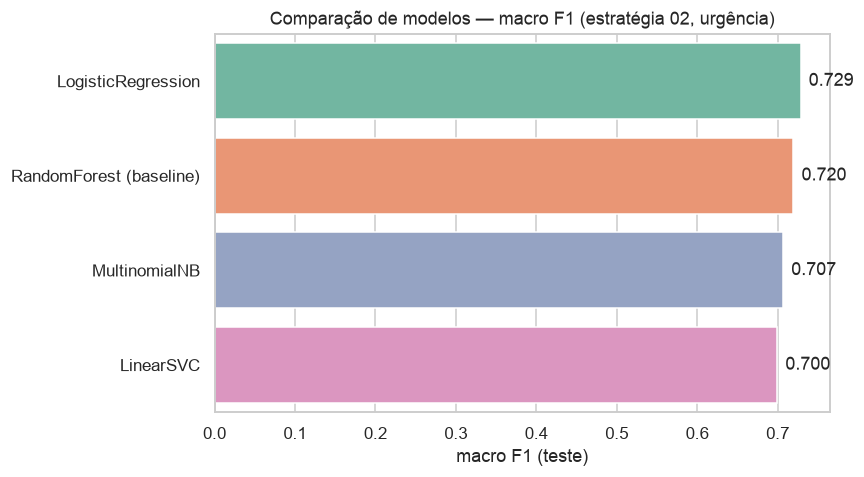

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.5))
order_models = results_table.sort_values("macro_f1", ascending=False).index.tolist()
sns.barplot(x=results_table.loc[order_models, "macro_f1"].astype(float), y=order_models,
            hue=order_models, legend=False, palette="Set2", ax=ax)
ax.set_xlabel("macro F1 (teste)")
ax.set_title("Comparação de modelos — macro F1 (estratégia 02, urgência)")
for i, m in enumerate(order_models):
    ax.text(float(results_table.loc[m, "macro_f1"]) + 0.01, i, f"{float(results_table.loc[m, 'macro_f1']):.3f}",
            va="center")
plt.tight_layout()
plt.show()

## Matrizes de confusão (LogisticRegression e LinearSVC, os dois melhores candidatos novos)

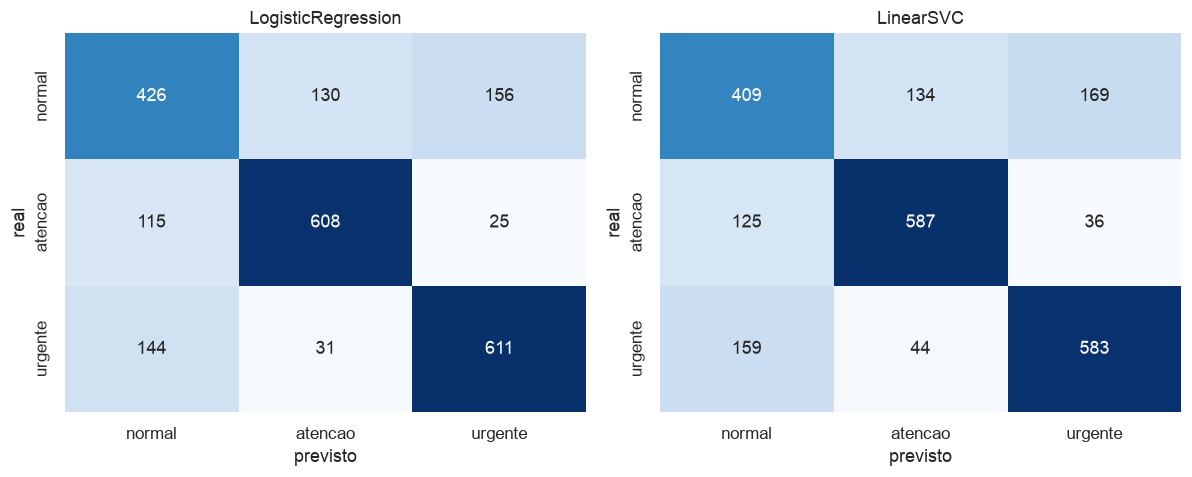

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name in zip(axes, ["LogisticRegression", "LinearSVC"], strict=True):
    sns.heatmap(confusions[name], annot=True, fmt="d", cmap="Blues",
                xticklabels=order_ma, yticklabels=order_ma,
                cbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("previsto")
    ax.set_ylabel("real")
plt.tight_layout()
plt.show()

## Error analysis — onde e por que os modelos erram

In [9]:
best_model_name = results_table["macro_f1"].astype(float).idxmax()
print(f"Melhor modelo por macro F1: {best_model_name}")

f1_by_class = {k: v for k, v in all_results[best_model_name]["per_class_f1"].items()
               if k not in ("macro avg", "weighted avg")}
worst_classes = sorted(f1_by_class.items(), key=lambda kv: kv[1])[:2]
print("Classes com pior F1 nesse modelo:", worst_classes)

Melhor modelo por macro F1: LogisticRegression
Classes com pior F1 nesse modelo: [('normal', 0.6099), ('urgente', 0.7744)]


In [10]:
best_pred = predictions[best_model_name]
y_test_arr = y_test.reset_index(drop=True)
x_test_arr = x_test.reset_index(drop=True)

for worst_class, f1 in worst_classes:
    mask_fn = (y_test_arr == worst_class) & (best_pred != worst_class)  # falsos negativos dessa classe
    confused_with = pd.Series(best_pred[mask_fn.values]).value_counts()
    print(f"\n=== {worst_class} (F1={f1:.3f}) ===")
    print(f"Falsos negativos: {mask_fn.sum()} de {(y_test_arr == worst_class).sum()} casos reais dessa classe")
    print(f"Confundida principalmente com: {dict(confused_with.head(2))}")
    print("Exemplos de erro (texto real, classe verdadeira, classe prevista):")
    examples = x_test_arr[mask_fn.values].head(2)
    preds_examples = pd.Series(best_pred[mask_fn.values]).head(2)
    for text, pred in zip(examples, preds_examples, strict=True):
        print(f"  [real={worst_class} | previsto={pred}] {text[:220]}...")


=== normal (F1=0.610) ===
Falsos negativos: 286 de 712 casos reais dessa classe
Confundida principalmente com: {'urgente': 156, 'atencao': 130}
Exemplos de erro (texto real, classe verdadeira, classe prevista):
  [real=normal | previsto=atencao] Late recurrence of a hepatocellular carcinoma in a patient with incomplete Alagille syndrome. In this study, the case of a patient presenting a second hepatocellular carcinoma 13 years after resection of a first tumor of...
  [real=normal | previsto=urgente] Renormalization of high cardiac output and of left ventricular size following long-term recombinant human erythropoietin treatment of anemic dialyzed uremic patients. To obtain information on the effects of the correctio...

=== urgente (F1=0.774) ===
Falsos negativos: 175 de 786 casos reais dessa classe
Confundida principalmente com: {'normal': 144, 'atencao': 31}
Exemplos de erro (texto real, classe verdadeira, classe prevista):
  [real=urgente | previsto=atencao] Hepatic giant cavernous

**Leitura:** as duas classes mais fracas do `LogisticRegression` são `normal` (F1=0,610) e `urgente`
(F1=0,774) — e, ao contrário do padrão visto na estratégia 03 (onde os erros convergiam todos para uma classe
"guarda-chuva"), aqui a confusão é **bidirecional entre extremos**: `normal` é confundida principalmente com
`urgente` (156 casos) e `atencao` (130), enquanto `urgente` é confundida majoritariamente com `normal` (144
casos) — quase tanto quanto com `atencao` (31). Isso é uma pista sobre a natureza do mapeamento condição→urgência
(notebook 02): duas condições médicas com vocabulário clínico parecido podem cair em baldes de urgência opostos
dependendo da regra de mapeamento, então o modelo aprende similaridade textual real, mas essa similaridade nem
sempre é preditiva da urgência atribuída. Isso não é um bug do classificador — é uma limitação inerente a
transformar um target de especialidade clínica em um target de gravidade por regra de mapeamento.

## Preprocessing — o que realmente ajuda? (experimentado, não assumido)

Testamos variações de preprocessing no melhor modelo (`LogisticRegression`), uma de cada vez, para ver o que
realmente muda o resultado — sem aplicar tudo de uma vez.

In [11]:
def eval_variant(vectorizer_kwargs, label):
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(**vectorizer_kwargs)),
        ("clf", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ])
    pipe.fit(x_train, y_train)
    pred = pipe.predict(x_test)
    macro_f1 = f1_score(y_test, pred, average="macro")
    print(f"{label:<45s} macro_f1={macro_f1:.4f}")
    return macro_f1


preprocessing_results = {}
preprocessing_results["baseline (max_features=5000, (1,2), stopwords en)"] = eval_variant(
    dict(max_features=5000, ngram_range=(1, 2), stop_words="english"),
    "baseline (max_features=5000, ngram(1,2), stopwords en)",
)
preprocessing_results["sem remoção de stopwords"] = eval_variant(
    dict(max_features=5000, ngram_range=(1, 2), stop_words=None),
    "sem remoção de stopwords",
)
preprocessing_results["só unigramas (1,1)"] = eval_variant(
    dict(max_features=5000, ngram_range=(1, 1), stop_words="english"),
    "só unigramas, ngram(1,1)",
)
preprocessing_results["vocabulário maior (max_features=20000)"] = eval_variant(
    dict(max_features=20000, ngram_range=(1, 2), stop_words="english"),
    "vocabulário maior, max_features=20000",
)

baseline (max_features=5000, ngram(1,2), stopwords en) macro_f1=0.7286


sem remoção de stopwords                      macro_f1=0.7201


só unigramas, ngram(1,1)                      macro_f1=0.7271


vocabulário maior, max_features=20000         macro_f1=0.7362


**Leitura:** ao contrário do que a estratégia 03 havia mostrado, aqui **aumentar o vocabulário ajuda**:
`max_features=20000` deu o melhor resultado da rodada (macro F1 0,7362, +0,76 p.p. sobre a config baseline de
5000 features). Remover stopwords continua piorando (0,7201) — o vocabulário técnico segue discriminativo por
si só. Como o ganho do vocabulário maior é real e mensurável (não uma prática "geralmente recomendada"),
adotamos `max_features=20000` na configuração final do `LogisticRegression` para o notebook 07.

## Consolidação

In [12]:
with open(f"{RESULTS_DIR}/model_comparison_results.json", "w") as f:
    json.dump({
        "strategy": "strategy02_urgency",
        "models": all_results,
        "best_model_by_macro_f1": best_model_name,
        "worst_classes": dict(worst_classes),
        "preprocessing_ablation": preprocessing_results,
    }, f, indent=2, ensure_ascii=False)
print("salvo em data/experiments/results/model_comparison_results.json")

salvo em data/experiments/results/model_comparison_results.json


### Conclusões

- **Achado principal:** `LogisticRegression` vence o baseline RandomForest em macro F1 (0,7286 vs. 0,7197)
  sendo **~213× menor** (310KB vs. 65.953KB) e **~39× mais rápido** na inferência (0,37ms vs. 14,58ms).
- `LinearSVC` (macro F1 0,6996) e `MultinomialNB` (macro F1 0,7069) ficaram **abaixo** do baseline RandomForest
  nesta estratégia — diferente do que se via na estratégia 03, onde os três modelos lineares superavam o RF.
  `LogisticRegression` é o único que bate o baseline aqui, e por margem clara.
- **CV vs. teste:** sem o artefato de duplicata com rótulo inconsistente (0% de duplicatas dentro do treino,
  confirmado acima) a CV (0,72 / 0,69 / 0,69) fica próxima do teste, sem o gap grande visto na estratégia 03 —
  confirma que aquele gap era mesmo um artefato de qualidade de dado do split oficial, não do método de CV.
- Error analysis mostra confusão bidirecional entre `normal` e `urgente` (ver acima) — sintoma do mapeamento
  condição→urgência gerar classes que nem sempre são separáveis por vocabulário textual puro.
- Preprocessing: aumentar o vocabulário para 20000 features **ajuda** aqui (0,7362, melhor resultado da
  rodada) — adotado na configuração final. Remover stopwords piora (0,7201).
- **Configuração final recomendada:** `LogisticRegression` com `TfidfVectorizer(max_features=20000,
  ngram_range=(1,2), stop_words="english")` — candidato para aprofundar latência e decidir a técnica de
  otimização no notebook 07.